# Prior Rollouts from MLP Prior Checkpoints

This notebook loads checkpoints from the `train_prior.py` -> `mlp_prior` pipeline and performs
prior-only rollouts (using only the prior and decoder, without encoder or trajectory observations).

You can set:
- A fixed logvar for sampling
- Use the network-predicted logvar per dimension
- Use deterministic mode (mean only)

## Imports and Setup

In [9]:
%load_ext autoreload
%autoreload 2

import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["MUJOCO_GL"] = "egl"  # Change to "osmesa" or "glfw" if needed
os.environ["PYOPENGL_PLATFORM"] = "egl"

from pathlib import Path
from typing import Any, Tuple

import jax
import jax.numpy as jnp
from jax import random
import imageio
import mediapy as media
import orbax.checkpoint as ocp
from omegaconf import OmegaConf

from brax.training import distribution
from brax.training.acme import running_statistics

from vnl_playground.tasks.rodent import imitation
from vnl_playground.tasks.rodent import wrappers as vnl_wrappers
from vnl_playground.tasks.rodent.reference_clips import ReferenceClips

from track_mjx.agent.mlp_prior import prior_networks
from track_mjx.agent.mlp_prior.prior_rollout_eval import (
    extract_prior_decoder_params,
    check_termination_nan,
    compute_world_zaxis_termination,
)

# Print JAX device information
print("=" * 50)
print("JAX DEVICE INFORMATION")
print("=" * 50)
print(f"JAX version: {jax.__version__}")
print(f"Default backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")
print(f"Device count: {jax.device_count()}")
print(f"Local device count: {jax.local_device_count()}")

if jax.default_backend() == "gpu":
    print("\nGPU is being used!")
    for i, device in enumerate(jax.devices()):
        print(f"  Device {i}: {device.device_kind} - {device.platform}")
else:
    print(f"\nWARNING: Using {jax.default_backend().upper()}, not GPU!")
    print("To use GPU, ensure CUDA is properly configured.")
print("=" * 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
JAX DEVICE INFORMATION
JAX version: 0.7.2
Default backend: gpu
Available devices: [CudaDevice(id=0)]
Device count: 1
Local device count: 1

GPU is being used!
  Device 0: Quadro RTX 8000 - gpu


## Configuration

Set your checkpoint path and rollout parameters here.

In [17]:
# ============ CONFIGURATION ============
# Path to your mlp_prior checkpoint
# NOTE: The checkpoint contains the config with data paths. If running from a different
# machine, you may need to update cfg.env_config paths after loading.
CHECKPOINT_PATH = (
    "/home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/260115_141734_544576"
)

# Checkpoint step to load (None = latest)
CHECKPOINT_STEP = None

# ============ STARTING POSE ============
# Options: "neutral" or "clip"
#   - "neutral": Start from the model's neutral pose (qpos0)
#   - "clip": Start from a specific clip and frame in the dataset
START_MODE = "clip"

# Only used if START_MODE = "clip"
CLIP_IDX = 1  # Which clip to start from
START_FRAME = 0  # Which frame within the clip

# ============ ROLLOUT SETTINGS ============
# Number of rollouts to perform
NUM_ROLLOUTS = 4

# Maximum steps per rollout
MAX_STEPS = 1000

# Prior sampling configuration
# Set DETERMINISTIC=True to use mean of prior (no sampling)
# Set DETERMINISTIC=False and configure logvar for sampling:
#   - USE_PREDICTED_LOGVAR=True: Use network-predicted logvar per dimension
#   - USE_PREDICTED_LOGVAR=False: Use FIXED_LOGVAR for all dimensions
DETERMINISTIC = False
USE_PREDICTED_LOGVAR = (
    False  # If True, uses network-predicted logvar (ignores FIXED_LOGVAR)
)
FIXED_LOGVAR = -1.0  # Only used if DETERMINISTIC=False and USE_PREDICTED_LOGVAR=False

# ============ RENDERING ============
RENDER_FPS = 50
CAMERA_NAME = "close_profile-rodent"
RENDER_HEIGHT = 480
RENDER_WIDTH = 640

# Set to True to save videos to disk, False to only render in notebook
SAVE_VIDEOS = False

# Random seed
SEED = 42

## Load Checkpoint

In [11]:
def load_mlp_prior_checkpoint(checkpoint_path: str, step: int | None = None):
    """Load an mlp_prior checkpoint.

    Args:
        checkpoint_path: Path to checkpoint directory.
        step: Specific step to load. If None, loads latest.

    Returns:
        Tuple of (config, policy_params)
    """
    step_prefix = "PriorNetwork"
    mgr_options = ocp.CheckpointManagerOptions(create=False, step_prefix=step_prefix)

    with ocp.CheckpointManager(checkpoint_path, options=mgr_options) as ckpt_mgr:
        if step is None:
            step = ckpt_mgr.latest_step()
        print(f"Loading checkpoint from {checkpoint_path} at step {step}")

        # Load config
        cfg = ckpt_mgr.restore(
            step,
            args=ocp.args.Composite(config=ocp.args.JsonRestore()),
        )["config"]
        cfg = OmegaConf.create(cfg)

        # Get prior layer sizes from config
        prior_hidden_layer_sizes = tuple(
            cfg.network_config.get(
                "prior_layer_sizes", cfg.network_config.encoder_layer_sizes
            )
        )

        # Create abstract policy for restoration using mlp_prior's function
        abstract_policy = prior_networks.create_abstract_prior_policy(
            cfg=OmegaConf.to_container(cfg),
            prior_hidden_layer_sizes=prior_hidden_layer_sizes,
        )

        # Load policy
        policy = ckpt_mgr.restore(
            step,
            args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
        )["policy"]

    return cfg, policy

In [12]:
# Load the checkpoint
cfg, policy_params = load_mlp_prior_checkpoint(str(CHECKPOINT_PATH), CHECKPOINT_STEP)

print(f"Action size: {cfg.network_config.action_size}")
print(f"Intention size: {cfg.network_config.intention_size}")

Loading checkpoint from /home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/260115_141734_544576 at step 9
Action size: 38
Intention size: 16


In [13]:
# Fix paths in config (replace /tmp/track-mjx with local path)
# Need to use OmegaConf.update() since DictConfig is read-only by default
from omegaconf import OmegaConf

OLD_PATH_PREFIX = "/tmp/track-mjx"
NEW_PATH_PREFIX = "/home/mila/a/aidan.sirbu/track-mjx"


def fix_path(path_str):
    if path_str and path_str.startswith(OLD_PATH_PREFIX):
        return path_str.replace(OLD_PATH_PREFIX, NEW_PATH_PREFIX, 1)
    return path_str


# Use OmegaConf.update to modify read-only DictConfig
OmegaConf.set_struct(cfg.env_config, False)
OmegaConf.update(
    cfg.env_config, "walker_xml_path", fix_path(cfg.env_config.walker_xml_path)
)
OmegaConf.update(
    cfg.env_config, "arena_xml_path", fix_path(cfg.env_config.arena_xml_path)
)
OmegaConf.update(
    cfg.env_config, "reference_data_path", fix_path(cfg.env_config.reference_data_path)
)
OmegaConf.set_struct(cfg.env_config, True)

print("Updated paths:")
print(f"  walker_xml_path: {cfg.env_config.walker_xml_path}")
print(f"  arena_xml_path: {cfg.env_config.arena_xml_path}")
print(f"  reference_data_path: {cfg.env_config.reference_data_path}")

Updated paths:
  walker_xml_path: /home/mila/a/aidan.sirbu/track-mjx/.venv/lib/python3.12/site-packages/vnl_playground/tasks/rodent/xmls/rodent.xml
  arena_xml_path: /home/mila/a/aidan.sirbu/track-mjx/.venv/lib/python3.12/site-packages/vnl_playground/tasks/rodent/xmls/arena.xml
  reference_data_path: /home/mila/a/aidan.sirbu/track-mjx/data/rodent/rodent_reference_clips.h5


## Create Environment

In [14]:
def create_environment(cfg):
    """Create the imitation environment from config.

    Does NOT use FlattenObsWrapper - returns dict observations like mlp_prior training.
    """
    from ml_collections import ConfigDict

    # Convert OmegaConf to ml_collections ConfigDict
    env_cfg = ConfigDict(OmegaConf.to_container(cfg.env_config, resolve=True))

    # Compute naconmax for warp backend (naconmax = nconmax * num_envs)
    # For single-environment rollouts, num_envs = 1
    if hasattr(env_cfg, "nconmax"):
        env_cfg.naconmax = env_cfg.nconmax * 1  # Single environment

    # Load reference clips
    reference_clips = ReferenceClips(
        data_path=cfg.env_config.reference_data_path,
        n_frames_per_clip=cfg.env_config.clip_length,
        keep_clips_idx=cfg.env_config.get("keep_clips_idx", None),
    )

    # Create environment WITHOUT FlattenObsWrapper to get dict observations
    env = imitation.Imitation(config=env_cfg, clips=reference_clips)

    return env

In [15]:
# Create the environment
env = create_environment(cfg)

# Get proprioceptive observation size from the config
# The config stores obs_sizes if using dict observations, otherwise use legacy format
if "obs_sizes" in cfg.network_config:
    proprioceptive_obs_size = cfg.network_config.obs_sizes["proprioception"]
elif "proprioceptive_obs_size" in cfg.network_config:
    proprioceptive_obs_size = cfg.network_config.proprioceptive_obs_size
else:
    # Fallback: compute from observation_size and reference_obs_size
    reference_obs_size = cfg.network_config.get("reference_obs_size", 0)
    proprioceptive_obs_size = cfg.network_config.observation_size - reference_obs_size

print(f"Proprioceptive observation size: {proprioceptive_obs_size}")

Proprioceptive observation size: 277


In [ ]:
# List available cameras in the model
print("Available cameras:")
for i in range(env.mj_model.ncam):
    cam_name = env.mj_model.camera(i).name
    print(f"  {i}: {cam_name}")

## Create Starting Pose

Create the initial state for rollouts - either from a neutral pose or from a specific clip/frame.

In [16]:
from mujoco import mjx


def create_neutral_state(env, rng_key):
    """Create an environment state initialized to the neutral pose.

    Uses env.reset() to get proper state structure, then replaces physics with neutral pose.
    """
    # First reset to get proper state structure
    state = env.reset(rng_key)

    mjx_model = env.mjx_model

    # Get neutral qpos from model
    neutral_qpos = jnp.array(env.mj_model.qpos0)
    # Adjust z-position to be zero
    neutral_qpos = neutral_qpos.at[2].set(0)

    # Replace physics data with neutral pose
    data = state.data.replace(qpos=neutral_qpos)
    data = data.replace(qvel=jnp.zeros(mjx_model.nv))
    data = mjx.forward(mjx_model, data)

    # Replace data in state (keep obs, metrics, info structure from reset)
    state = state.replace(data=data)

    return state


def create_clip_state(env, clip_idx: int, start_frame: int, rng_key):
    """Create an environment state initialized from a specific clip and frame.

    Uses env.reset() to get proper state structure, then replaces physics with clip pose.
    """
    # First reset to get proper state structure
    state = env.reset(rng_key)

    # Access the unwrapped Imitation environment to get reference_clips
    unwrapped_env = env
    while hasattr(unwrapped_env, "_env"):
        unwrapped_env = unwrapped_env._env

    # Get reference data at specified clip and frame
    reference = unwrapped_env.reference_clips.at(clip=clip_idx, frame=start_frame)

    mjx_model = env.mjx_model

    # Replace physics data with clip pose
    data = state.data.replace(qpos=reference.qpos)
    data = data.replace(qvel=jnp.zeros(mjx_model.nv))  # zeros like default config
    data = mjx.forward(mjx_model, data)

    # Update info with correct clip/frame
    info = dict(state.info)
    info["start_frame"] = start_frame
    info["reference_clip"] = clip_idx

    # Replace data and info in state
    state = state.replace(data=data, info=info)

    return state


def get_starting_state(
    env, mode: str, clip_idx: int = 0, start_frame: int = 0, rng_key=None
):
    """Get the starting state based on the configured mode.

    Args:
        env: The environment.
        mode: "neutral" or "clip".
        clip_idx: Clip index (only used if mode="clip").
        start_frame: Start frame (only used if mode="clip").
        rng_key: Random key for env.reset() to get proper state structure.

    Returns:
        Initial state for rollouts.
    """
    if rng_key is None:
        rng_key = jax.random.PRNGKey(0)

    if mode == "neutral":
        return create_neutral_state(env, rng_key)
    elif mode == "clip":
        return create_clip_state(env, clip_idx, start_frame, rng_key)
    else:
        raise ValueError(f"Unknown start mode: {mode}. Use 'neutral' or 'clip'.")

In [ ]:
# Create the starting state
rng_init = jax.random.PRNGKey(SEED)
starting_state = get_starting_state(
    env, START_MODE, CLIP_IDX, START_FRAME, rng_key=rng_init
)

if START_MODE == "neutral":
    print("Starting pose: Neutral (model's default qpos0)")
else:
    print(f"Starting pose: Clip {CLIP_IDX}, Frame {START_FRAME}")

Starting pose: Clip 1, Frame 0


### Preview Starting Pose

Render the starting pose to verify it looks correct before running rollouts.

Starting pose preview (clip mode):


""

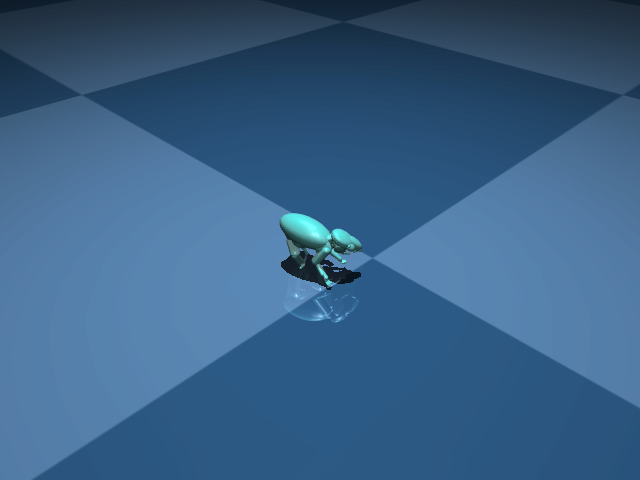

In [27]:
# Render a single frame of the starting pose
starting_frames = env.render(
    [starting_state], camera=CAMERA_NAME, height=RENDER_HEIGHT, width=RENDER_WIDTH
)

print(f"Starting pose preview ({START_MODE} mode):")
media.show_image(starting_frames[0])

## Create Prior Policy

This creates a policy that uses only the prior and decoder networks (no encoder, no trajectory observations).

Uses the `mlp_prior` module's Prior and Decoder classes.

In [ ]:
from typing import Optional

from track_mjx.agent.observation_utils import (
    DictRunningStatisticsState,
    flatten_obs_dict,
)


def reparameterize(rng: jax.Array, mean: jax.Array, logvar: jax.Array) -> jax.Array:
    """Sample from a Gaussian distribution using the reparameterization trick."""
    std = jnp.exp(0.5 * logvar)
    eps = random.normal(rng, logvar.shape)
    return mean + eps * std


def create_prior_policy(
    policy_params: Tuple,
    action_size: int,
    proprioceptive_obs_size: int,
    intention_latent_size: int,
    decoder_hidden_layer_sizes: Tuple[int, ...],
    prior_hidden_layer_sizes: Tuple[int, ...],
    fixed_logvar: Optional[float] = -2.0,
    deterministic: bool = False,
):
    """Create a policy function that uses only prior and decoder.

    Uses the mlp_prior module's Prior and Decoder classes.
    Handles both dict normalizer params (DictRunningStatisticsState) and legacy flat params.

    Args:
        policy_params: Tuple of (normalizer_params, network_params).
        action_size: Size of action space.
        proprioceptive_obs_size: Size of proprioceptive observations.
        intention_latent_size: Size of latent space.
        decoder_hidden_layer_sizes: Decoder hidden layer sizes.
        prior_hidden_layer_sizes: Prior hidden layer sizes.
        fixed_logvar: Fixed log-variance for sampling. If None, uses the
            network-predicted logvar per dimension.
        deterministic: If True, use mean instead of sampling.

    Returns:
        Policy function (obs, rng) -> (action, extras)
    """
    # Extract parameters using mlp_prior's function
    prior_params, decoder_params, normalizer_params = extract_prior_decoder_params(
        policy_params
    )

    # Handle both dict and legacy normalizer params
    if isinstance(normalizer_params, DictRunningStatisticsState):
        # New dict-based normalizer - extract proprioception normalizer
        proprio_normalizer_params = normalizer_params.proprioception
    else:
        # Legacy flat normalizer - extract proprioceptive portion (last part)
        proprio_normalizer_params = running_statistics.RunningStatisticsState(
            count=normalizer_params.count,
            mean=normalizer_params.mean[-proprioceptive_obs_size:],
            summed_variance=normalizer_params.summed_variance[
                -proprioceptive_obs_size:
            ],
            std=normalizer_params.std[-proprioceptive_obs_size:],
        )

    # Create action distribution
    parametric_action_distribution = distribution.NormalTanhDistribution(
        event_size=action_size
    )

    # Create prior and decoder modules using mlp_prior classes
    prior_module = prior_networks.Prior(
        layer_sizes=list(prior_hidden_layer_sizes),
        latents=intention_latent_size,
    )

    decoder_module = prior_networks.Decoder(
        layer_sizes=list(decoder_hidden_layer_sizes)
        + [parametric_action_distribution.param_size],
    )

    def policy_fn(obs: jax.Array, rng_key: jax.Array) -> Tuple[jax.Array, dict]:
        """Generate actions from proprioceptive observations using prior + decoder.

        Args:
            obs: Proprioceptive observations (already extracted and flattened).
            rng_key: Random key for sampling.
        """
        key_sample, key_action = random.split(rng_key)

        # Normalize observations
        normalized_obs = running_statistics.normalize(obs, proprio_normalizer_params)

        # Get prior distribution
        prior_mean, prior_logvar = prior_module.apply(
            {"params": prior_params}, normalized_obs
        )

        # Determine which logvar to use for sampling
        if fixed_logvar is not None:
            # Use fixed logvar for more stable sampling
            logvar_for_sampling = jnp.full_like(prior_mean, fixed_logvar)
        else:
            # Use network-predicted logvar per dimension
            logvar_for_sampling = prior_logvar

        # Sample from prior
        if deterministic:
            z = prior_mean
        else:
            z = reparameterize(key_sample, prior_mean, logvar_for_sampling)

        # Decode to action distribution parameters
        decoder_input = jnp.concatenate([z, normalized_obs], axis=-1)
        logits, _ = decoder_module.apply({"params": decoder_params}, decoder_input)

        # Always take mode of action distribution
        action = parametric_action_distribution.mode(logits)

        extras = {
            "prior_mean": prior_mean,
            "prior_logvar": prior_logvar,
            "intention": z,
            "logits": logits,
        }

        return action, extras

    return policy_fn

In [ ]:
# Create the prior policy
# Use None for fixed_logvar when USE_PREDICTED_LOGVAR is True
logvar_to_use = None if USE_PREDICTED_LOGVAR else FIXED_LOGVAR

prior_policy = create_prior_policy(
    policy_params=policy_params,
    action_size=cfg.network_config.action_size,
    proprioceptive_obs_size=proprioceptive_obs_size,
    intention_latent_size=cfg.network_config.intention_size,
    decoder_hidden_layer_sizes=tuple(cfg.network_config.decoder_layer_sizes),
    prior_hidden_layer_sizes=tuple(
        cfg.network_config.get(
            "prior_layer_sizes", cfg.network_config.encoder_layer_sizes
        )
    ),
    fixed_logvar=logvar_to_use,
    deterministic=DETERMINISTIC,
)

if DETERMINISTIC:
    print("Created prior policy (deterministic, using mean)")
elif USE_PREDICTED_LOGVAR:
    print("Created prior policy (stochastic, using network-predicted logvar)")
else:
    print(f"Created prior policy (stochastic, fixed_logvar={FIXED_LOGVAR})")

## Vectorized Prior Rollout

Perform multiple rollouts in parallel using `jax.lax.scan` (no for loops) and `jax.vmap`.

In [ ]:
def create_vectorized_rollout_fn(env, policy_fn, max_steps: int, starting_state):
    """Create a vectorized rollout function that starts from a fixed initial state.

    Uses jax.lax.scan for single rollout (no for loop) and jax.vmap for parallel rollouts.
    All rollouts start from the same initial state but with different random keys for actions.

    Args:
        env: The environment.
        policy_fn: Policy function (obs, rng) -> (action, extras).
        max_steps: Maximum steps per rollout.
        starting_state: The initial state for all rollouts.

    Returns:
        Tuple of (vmapped_rollout_fn, jit_step)
    """
    jit_step = jax.jit(env.step)

    def single_rollout_fn(rng_key: jax.Array):
        """Run a single prior rollout from the fixed starting state."""
        # Start from the provided starting state (same for all rollouts)
        state = starting_state

        def step_fn(carry, _):
            state, key, nan_terminated = carry
            key, key_action = random.split(key)

            # Get proprioceptive observations from dict observations
            if hasattr(state.obs, "get") or isinstance(state.obs, dict):
                # Dict observations - use flatten_obs_dict
                flat_obs = flatten_obs_dict(state.obs)
                proprio = flat_obs["proprioception"]
            else:
                # Legacy flat observations - proprioception is the last part
                # This shouldn't happen with dict observations enabled
                proprio = state.obs

            # Get action from prior policy
            action, _ = policy_fn(proprio, key_action)

            # Step environment
            next_state = jit_step(state, action)

            # Check for NaN (cheap, run every step)
            step_nan = check_termination_nan(next_state.data)
            new_nan_terminated = jnp.logical_or(nan_terminated, step_nan)

            return (next_state, key, new_nan_terminated), next_state

        initial_carry = (state, rng_key, jnp.array(False))
        (_, _, nan_terminated), all_states = jax.lax.scan(
            step_fn, initial_carry, None, length=max_steps
        )

        # Compute world z-axis termination AFTER rollout (batch compute)
        upside_down_flags = compute_world_zaxis_termination(env, all_states.data)

        # Find first termination step
        any_upside_down = jnp.any(upside_down_flags)
        first_upside_down_step = jnp.argmax(upside_down_flags)

        # Combine termination conditions
        terminated = jnp.logical_or(nan_terminated, any_upside_down)
        step_count = jnp.where(any_upside_down, first_upside_down_step + 1, max_steps)

        return step_count, terminated, all_states

    # Vmap and jit the rollout function
    vmapped_rollout = jax.jit(jax.vmap(single_rollout_fn))

    return vmapped_rollout, jit_step

In [ ]:
# Create the vectorized rollout function with the configured starting state
vmapped_rollout, jit_step = create_vectorized_rollout_fn(
    env=env,
    policy_fn=prior_policy,
    max_steps=MAX_STEPS,
    starting_state=starting_state,
)

print(
    f"Created vectorized rollout function for {NUM_ROLLOUTS} rollouts of {MAX_STEPS} steps each"
)
print(
    f"All rollouts will start from: {START_MODE}"
    + (f" (clip {CLIP_IDX}, frame {START_FRAME})" if START_MODE == "clip" else "")
)

In [ ]:
# Generate random keys for rollouts
rng = random.PRNGKey(SEED)
rollout_keys = random.split(rng, NUM_ROLLOUTS)

# Run all rollouts in parallel (first run will compile)
print("Running rollouts (first run includes compilation time)...")
import time

t_start = time.time()

step_counts, terminated_flags, all_rollout_states = vmapped_rollout(rollout_keys)

# Block until complete
step_counts = jnp.array(step_counts)
step_counts.block_until_ready()

print(f"Completed {NUM_ROLLOUTS} rollouts in {time.time() - t_start:.2f}s")
print(f"Step counts: {step_counts}")
print(f"Termination rate: {jnp.mean(terminated_flags.astype(jnp.float32)):.2%}")
print(f"Average steps: {jnp.mean(step_counts):.1f}")
print(f"Max steps reached: {jnp.sum(step_counts >= MAX_STEPS)}/{NUM_ROLLOUTS}")

## Render Rollouts

Render each rollout to video.

In [ ]:
def render_rollout(
    env, states, num_steps: int, camera: str, height: int = 480, width: int = 640
):
    """Render a rollout to frames.

    Args:
        env: The environment.
        states: Stacked states from rollout (shape: [max_steps, ...]).
        num_steps: Number of steps to render.
        camera: Camera name for rendering.
        height: Frame height.
        width: Frame width.

    Returns:
        List of frames (numpy arrays).
    """
    # Convert stacked states to list
    states_list = []
    for i in range(num_steps):
        state_i = jax.tree_util.tree_map(lambda x: x[i], states)
        states_list.append(state_i)

    # Render all frames at once
    frames = env.render(states_list, camera=camera, height=height, width=width)

    return frames

In [ ]:
# Render rollouts
if SAVE_VIDEOS:
    output_dir = Path(CHECKPOINT_PATH) / "prior_rollouts"
    output_dir.mkdir(exist_ok=True)
    print(f"Rendering and saving {NUM_ROLLOUTS} rollouts to {output_dir}")
else:
    print(f"Rendering {NUM_ROLLOUTS} rollouts (not saving to disk)")

all_videos = []
for i in range(NUM_ROLLOUTS):
    # Extract states for this rollout
    rollout_states = jax.tree_util.tree_map(lambda x: x[i], all_rollout_states)
    step_count = int(step_counts[i])

    print(
        f"  Rendering rollout {i+1}/{NUM_ROLLOUTS} (terminated at step {step_count}, rendering all {MAX_STEPS})..."
    )

    # Render all frames (including post-termination)
    frames = render_rollout(
        env=env,
        states=rollout_states,
        num_steps=MAX_STEPS,
        camera=CAMERA_NAME,
        height=RENDER_HEIGHT,
        width=RENDER_WIDTH,
    )

    all_videos.append(frames)

    # Save video if enabled
    if SAVE_VIDEOS:
        if DETERMINISTIC:
            mode_str = "deterministic"
        elif USE_PREDICTED_LOGVAR:
            mode_str = "predicted_logvar"
        else:
            mode_str = f"logvar{FIXED_LOGVAR}"
        start_str = (
            "neutral"
            if START_MODE == "neutral"
            else f"clip{CLIP_IDX}_frame{START_FRAME}"
        )
        video_path = output_dir / f"prior_rollout_{i:02d}_{start_str}_{mode_str}.mp4"

        with imageio.get_writer(str(video_path), fps=RENDER_FPS) as writer:
            for frame in frames:
                writer.append_data(frame)
        print(f"    Saved to {video_path}")

print(f"\nRendering complete!")

## Display Videos

In [ ]:
media.show_video(all_videos[0], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[3], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[0], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[3], fps=RENDER_FPS)

### logvar = 0.0

In [ ]:
media.show_video(all_videos[0], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[1], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[2], fps=RENDER_FPS)

### Predicted variance

In [ ]:
media.show_video(all_videos[0], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[1], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[2], fps=RENDER_FPS)

### deterministic

In [ ]:
media.show_video(all_videos[0], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[0], fps=RENDER_FPS)

### logvar = -2.0

In [ ]:
media.show_video(all_videos[0], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[1], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[2], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[3], fps=RENDER_FPS)

### logvar = 0.0

In [ ]:
media.show_video(all_videos[0], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[1], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[2], fps=RENDER_FPS)

In [ ]:
media.show_video(all_videos[3], fps=RENDER_FPS)

In [ ]:
# Display rollout 1
if len(all_videos) > 1:
    print(f"Displaying rollout 1 ({len(all_videos[1])} frames)")
    media.show_video(all_videos[1], fps=RENDER_FPS)

In [ ]:
# Display the best (longest) rollout
best_idx = int(jnp.argmax(step_counts))
print(f"Displaying best rollout (index {best_idx}, {int(step_counts[best_idx])} steps)")
media.show_video(all_videos[best_idx], fps=RENDER_FPS)

## Summary Statistics

In [ ]:
print("=" * 50)
print("PRIOR ROLLOUT SUMMARY (MLP Prior Checkpoint)")
print("=" * 50)
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(
    f"Starting pose: {START_MODE}"
    + (
        f" (clip {CLIP_IDX}, frame {START_FRAME})"
        if START_MODE == "clip"
        else " (model qpos0)"
    )
)
if DETERMINISTIC:
    policy_mode = "Deterministic (mean)"
elif USE_PREDICTED_LOGVAR:
    policy_mode = "Stochastic (network-predicted logvar)"
else:
    policy_mode = f"Stochastic (fixed_logvar={FIXED_LOGVAR})"
print(f"Policy mode: {policy_mode}")
print(f"Number of rollouts: {NUM_ROLLOUTS}")
print(f"Max steps: {MAX_STEPS}")
print()
print("Results:")
print(f"  Average steps: {float(jnp.mean(step_counts)):.1f}")
print(f"  Std steps: {float(jnp.std(step_counts)):.1f}")
print(f"  Min steps: {int(jnp.min(step_counts))}")
print(f"  Max steps: {int(jnp.max(step_counts))}")
print(f"  Termination rate: {float(jnp.mean(terminated_flags)):.1%}")
print(f"  Max steps reached: {int(jnp.sum(step_counts >= MAX_STEPS))}/{NUM_ROLLOUTS}")
print("=" * 50)

# Multi Rollout

Self-contained section for running multiple rollouts across different variance settings and starting poses.

Run the imports at the top of the notebook, then jump straight here.

In [34]:
# ==================== MULTI ROLLOUT CONFIGURATION ====================
# This cell contains ALL configuration for the Multi Rollout section.
# After running imports at the top, you can jump straight here.

# ============ CHECKPOINT ============
MULTI_CHECKPOINT_PATH = (
    "/home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/260115_141734_544576"
)
MULTI_CHECKPOINT_STEP = None  # None = latest

# ============ VARIANCE SETTINGS TO TEST ============
# List of fixed logvar values to test (in addition to deterministic and predicted)
FIXED_LOGVAR_VALUES = [-4.0, -3.0, -2.0, -1.0, -0.5, 0.0]

# ============ STARTING POSES ============
# Clips to use for clip-based rollouts (list of (clip_idx, start_frame) tuples)
# Each entry will generate one rollout per variance setting
CLIP_CONFIGS = [
    (2, 0),  # Clip 0, frame 0
    (3, 0),  # Clip 1, frame 0
    (4, 0),  # Clip 2, frame 0
]

# ============ ROLLOUT SETTINGS ============
MULTI_MAX_STEPS = 1000
MULTI_NUM_ROLLOUTS_PER_CONFIG = (
    1  # Number of rollouts per (variance, starting_pose) combo
)

# ============ RENDERING ============
MULTI_RENDER_FPS = 50
MULTI_CAMERA_NAME = "close_profile-rodent"
MULTI_RENDER_HEIGHT = 480
MULTI_RENDER_WIDTH = 640

# Save videos to disk (if False, only display in notebook)
MULTI_SAVE_VIDEOS = False

# ============ RANDOM SEED ============
MULTI_SEED = 42

# ============ PATH FIXING ============
# For checkpoints saved on cluster with different paths
OLD_PATH_PREFIX = "/tmp/track-mjx"
NEW_PATH_PREFIX = "/home/mila/a/aidan.sirbu/track-mjx"

print("Multi Rollout Configuration:")
print(f"  Checkpoint: {MULTI_CHECKPOINT_PATH}")
print(
    f"  Variance settings: deterministic, predicted_logvar, fixed_logvar={FIXED_LOGVAR_VALUES}"
)
print(f"  Starting poses: neutral + {len(CLIP_CONFIGS)} clips")
print(
    f"  Total rollout configs: {(2 + len(FIXED_LOGVAR_VALUES)) * (1 + len(CLIP_CONFIGS))}"
)

Multi Rollout Configuration:
  Checkpoint: /home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/260115_141734_544576
  Variance settings: deterministic, predicted_logvar, fixed_logvar=[-4.0, -3.0, -2.0, -1.0, -0.5, 0.0]
  Starting poses: neutral + 3 clips
  Total rollout configs: 32


In [35]:
# ==================== MULTI ROLLOUT HELPER FUNCTIONS ====================
# All functions needed for multi-rollout are defined here for self-containment.

from mujoco import mjx
from ml_collections import ConfigDict
from typing import Optional, Tuple, Any, List, Dict

from track_mjx.agent.observation_utils import (
    DictRunningStatisticsState,
    flatten_obs_dict,
)


def multi_load_checkpoint(checkpoint_path: str, step: int | None = None):
    """Load an mlp_prior checkpoint."""
    step_prefix = "PriorNetwork"
    mgr_options = ocp.CheckpointManagerOptions(create=False, step_prefix=step_prefix)

    with ocp.CheckpointManager(checkpoint_path, options=mgr_options) as ckpt_mgr:
        if step is None:
            step = ckpt_mgr.latest_step()
        print(f"Loading checkpoint from {checkpoint_path} at step {step}")

        cfg = ckpt_mgr.restore(
            step,
            args=ocp.args.Composite(config=ocp.args.JsonRestore()),
        )["config"]
        cfg = OmegaConf.create(cfg)

        prior_hidden_layer_sizes = tuple(
            cfg.network_config.get(
                "prior_layer_sizes", cfg.network_config.encoder_layer_sizes
            )
        )

        abstract_policy = prior_networks.create_abstract_prior_policy(
            cfg=OmegaConf.to_container(cfg),
            prior_hidden_layer_sizes=prior_hidden_layer_sizes,
        )

        policy = ckpt_mgr.restore(
            step,
            args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
        )["policy"]

    return cfg, policy


def multi_fix_paths(cfg, old_prefix: str, new_prefix: str):
    """Fix paths in config."""

    def fix_path(path_str):
        if path_str and path_str.startswith(old_prefix):
            return path_str.replace(old_prefix, new_prefix, 1)
        return path_str

    OmegaConf.set_struct(cfg.env_config, False)
    OmegaConf.update(
        cfg.env_config, "walker_xml_path", fix_path(cfg.env_config.walker_xml_path)
    )
    OmegaConf.update(
        cfg.env_config, "arena_xml_path", fix_path(cfg.env_config.arena_xml_path)
    )
    OmegaConf.update(
        cfg.env_config,
        "reference_data_path",
        fix_path(cfg.env_config.reference_data_path),
    )
    OmegaConf.set_struct(cfg.env_config, True)
    return cfg


def multi_create_environment(cfg):
    """Create the imitation environment from config."""
    env_cfg = ConfigDict(OmegaConf.to_container(cfg.env_config, resolve=True))
    if hasattr(env_cfg, "nconmax"):
        env_cfg.naconmax = env_cfg.nconmax * 1

    reference_clips = ReferenceClips(
        data_path=cfg.env_config.reference_data_path,
        n_frames_per_clip=cfg.env_config.clip_length,
        keep_clips_idx=cfg.env_config.get("keep_clips_idx", None),
    )

    env = imitation.Imitation(config=env_cfg, clips=reference_clips)
    return env


def multi_create_neutral_state(env, rng_key):
    """Create state initialized to neutral pose."""
    state = env.reset(rng_key)
    mjx_model = env.mjx_model
    neutral_qpos = jnp.array(env.mj_model.qpos0)
    neutral_qpos = neutral_qpos.at[2].set(0)
    data = state.data.replace(qpos=neutral_qpos)
    data = data.replace(qvel=jnp.zeros(mjx_model.nv))
    data = mjx.forward(mjx_model, data)
    state = state.replace(data=data)
    return state


def multi_create_clip_state(env, clip_idx: int, start_frame: int, rng_key):
    """Create state initialized from a specific clip and frame."""
    state = env.reset(rng_key)
    unwrapped_env = env
    while hasattr(unwrapped_env, "_env"):
        unwrapped_env = unwrapped_env._env

    reference = unwrapped_env.reference_clips.at(clip=clip_idx, frame=start_frame)
    mjx_model = env.mjx_model
    data = state.data.replace(qpos=reference.qpos)
    data = data.replace(qvel=jnp.zeros(mjx_model.nv))
    data = mjx.forward(mjx_model, data)

    info = dict(state.info)
    info["start_frame"] = start_frame
    info["reference_clip"] = clip_idx
    state = state.replace(data=data, info=info)
    return state


def multi_reparameterize(
    rng: jax.Array, mean: jax.Array, logvar: jax.Array
) -> jax.Array:
    """Sample from a Gaussian using reparameterization trick."""
    std = jnp.exp(0.5 * logvar)
    eps = random.normal(rng, logvar.shape)
    return mean + eps * std


def multi_create_prior_policy(
    policy_params: Tuple,
    action_size: int,
    proprioceptive_obs_size: int,
    intention_latent_size: int,
    decoder_hidden_layer_sizes: Tuple[int, ...],
    prior_hidden_layer_sizes: Tuple[int, ...],
    fixed_logvar: Optional[float] = -2.0,
    deterministic: bool = False,
):
    """Create a policy function that uses only prior and decoder."""
    prior_params, decoder_params, normalizer_params = extract_prior_decoder_params(
        policy_params
    )

    if isinstance(normalizer_params, DictRunningStatisticsState):
        proprio_normalizer_params = normalizer_params.proprioception
    else:
        proprio_normalizer_params = running_statistics.RunningStatisticsState(
            count=normalizer_params.count,
            mean=normalizer_params.mean[-proprioceptive_obs_size:],
            summed_variance=normalizer_params.summed_variance[
                -proprioceptive_obs_size:
            ],
            std=normalizer_params.std[-proprioceptive_obs_size:],
        )

    parametric_action_distribution = distribution.NormalTanhDistribution(
        event_size=action_size
    )

    prior_module = prior_networks.Prior(
        layer_sizes=list(prior_hidden_layer_sizes),
        latents=intention_latent_size,
    )

    decoder_module = prior_networks.Decoder(
        layer_sizes=list(decoder_hidden_layer_sizes)
        + [parametric_action_distribution.param_size],
    )

    def policy_fn(obs: jax.Array, rng_key: jax.Array) -> Tuple[jax.Array, dict]:
        key_sample, key_action = random.split(rng_key)
        normalized_obs = running_statistics.normalize(obs, proprio_normalizer_params)

        prior_mean, prior_logvar = prior_module.apply(
            {"params": prior_params}, normalized_obs
        )

        if fixed_logvar is not None:
            logvar_for_sampling = jnp.full_like(prior_mean, fixed_logvar)
        else:
            logvar_for_sampling = prior_logvar

        if deterministic:
            z = prior_mean
        else:
            z = multi_reparameterize(key_sample, prior_mean, logvar_for_sampling)

        decoder_input = jnp.concatenate([z, normalized_obs], axis=-1)
        logits, _ = decoder_module.apply({"params": decoder_params}, decoder_input)
        action = parametric_action_distribution.mode(logits)

        return action, {
            "prior_mean": prior_mean,
            "prior_logvar": prior_logvar,
            "intention": z,
        }

    return policy_fn


def multi_create_vectorized_rollout_fn(env, policy_fn, max_steps: int, starting_state):
    """Create a vectorized rollout function."""
    jit_step = jax.jit(env.step)

    def single_rollout_fn(rng_key: jax.Array):
        state = starting_state

        def step_fn(carry, _):
            state, key, nan_terminated = carry
            key, key_action = random.split(key)

            if hasattr(state.obs, "get") or isinstance(state.obs, dict):
                flat_obs = flatten_obs_dict(state.obs)
                proprio = flat_obs["proprioception"]
            else:
                proprio = state.obs

            action, _ = policy_fn(proprio, key_action)
            next_state = jit_step(state, action)

            step_nan = check_termination_nan(next_state.data)
            new_nan_terminated = jnp.logical_or(nan_terminated, step_nan)

            return (next_state, key, new_nan_terminated), next_state

        initial_carry = (state, rng_key, jnp.array(False))
        (_, _, nan_terminated), all_states = jax.lax.scan(
            step_fn, initial_carry, None, length=max_steps
        )

        upside_down_flags = compute_world_zaxis_termination(env, all_states.data)
        any_upside_down = jnp.any(upside_down_flags)
        first_upside_down_step = jnp.argmax(upside_down_flags)

        terminated = jnp.logical_or(nan_terminated, any_upside_down)
        step_count = jnp.where(any_upside_down, first_upside_down_step + 1, max_steps)

        return step_count, terminated, all_states

    vmapped_rollout = jax.jit(jax.vmap(single_rollout_fn))
    return vmapped_rollout, jit_step


def multi_render_rollout(
    env, states, num_steps: int, camera: str, height: int = 480, width: int = 640
):
    """Render a rollout to frames."""
    states_list = []
    for i in range(num_steps):
        state_i = jax.tree_util.tree_map(lambda x: x[i], states)
        states_list.append(state_i)
    frames = env.render(states_list, camera=camera, height=height, width=width)
    return frames


print("Multi-rollout helper functions defined.")

Multi-rollout helper functions defined.


In [36]:
# ==================== LOAD CHECKPOINT AND CREATE ENVIRONMENT ====================

# Load checkpoint
multi_cfg, multi_policy_params = multi_load_checkpoint(
    MULTI_CHECKPOINT_PATH, MULTI_CHECKPOINT_STEP
)

# Fix paths
multi_cfg = multi_fix_paths(multi_cfg, OLD_PATH_PREFIX, NEW_PATH_PREFIX)

# Create environment
multi_env = multi_create_environment(multi_cfg)

# Get proprioceptive observation size
if "obs_sizes" in multi_cfg.network_config:
    multi_proprio_obs_size = multi_cfg.network_config.obs_sizes["proprioception"]
elif "proprioceptive_obs_size" in multi_cfg.network_config:
    multi_proprio_obs_size = multi_cfg.network_config.proprioceptive_obs_size
else:
    reference_obs_size = multi_cfg.network_config.get("reference_obs_size", 0)
    multi_proprio_obs_size = (
        multi_cfg.network_config.observation_size - reference_obs_size
    )

print(f"\nEnvironment created successfully")
print(f"  Action size: {multi_cfg.network_config.action_size}")
print(f"  Proprioceptive obs size: {multi_proprio_obs_size}")

Loading checkpoint from /home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/260115_141734_544576 at step 10

Environment created successfully
  Action size: 38
  Proprioceptive obs size: 277


In [37]:
# ==================== BUILD VARIANCE CONFIGURATIONS ====================
# Each variance config is a dict with keys: name, deterministic, fixed_logvar (or None for predicted)

variance_configs = []

# Deterministic (mean only)
variance_configs.append(
    {
        "name": "deterministic",
        "deterministic": True,
        "fixed_logvar": None,
    }
)

# Predicted logvar (network-predicted per dimension)
variance_configs.append(
    {
        "name": "predicted_logvar",
        "deterministic": False,
        "fixed_logvar": None,
    }
)

# Fixed logvar values
for logvar in FIXED_LOGVAR_VALUES:
    variance_configs.append(
        {
            "name": f"logvar_{logvar:.1f}",
            "deterministic": False,
            "fixed_logvar": logvar,
        }
    )

# Build starting pose configurations
starting_pose_configs = []

# Neutral pose
starting_pose_configs.append(
    {
        "name": "neutral",
        "mode": "neutral",
        "clip_idx": None,
        "start_frame": None,
    }
)

# Clip poses
for clip_idx, start_frame in CLIP_CONFIGS:
    starting_pose_configs.append(
        {
            "name": f"clip{clip_idx}_frame{start_frame}",
            "mode": "clip",
            "clip_idx": clip_idx,
            "start_frame": start_frame,
        }
    )

print(f"Variance configurations ({len(variance_configs)}):")
for vc in variance_configs:
    print(f"  - {vc['name']}")

print(f"\nStarting pose configurations ({len(starting_pose_configs)}):")
for sp in starting_pose_configs:
    print(f"  - {sp['name']}")

print(
    f"\nTotal rollout combinations: {len(variance_configs) * len(starting_pose_configs)}"
)

Variance configurations (8):
  - deterministic
  - predicted_logvar
  - logvar_-4.0
  - logvar_-3.0
  - logvar_-2.0
  - logvar_-1.0
  - logvar_-0.5
  - logvar_0.0

Starting pose configurations (4):
  - neutral
  - clip2_frame0
  - clip3_frame0
  - clip4_frame0

Total rollout combinations: 32


In [38]:
# ==================== RUN ALL ROLLOUTS ====================
import time

# Storage for all results
# Structure: multi_results[variance_name][pose_name] = {"step_counts", "terminated", "states", "frames"}
multi_results = {}

# Create output directory if saving videos
if MULTI_SAVE_VIDEOS:
    multi_output_dir = Path(MULTI_CHECKPOINT_PATH) / "multi_rollouts"
    multi_output_dir.mkdir(exist_ok=True)
    print(f"Videos will be saved to: {multi_output_dir}")

# Initialize RNG
multi_rng = random.PRNGKey(MULTI_SEED)

# Get network config parameters once
multi_action_size = multi_cfg.network_config.action_size
multi_intention_size = multi_cfg.network_config.intention_size
multi_decoder_layers = tuple(multi_cfg.network_config.decoder_layer_sizes)
multi_prior_layers = tuple(
    multi_cfg.network_config.get(
        "prior_layer_sizes", multi_cfg.network_config.encoder_layer_sizes
    )
)

total_start_time = time.time()

# Loop through all variance configurations
for var_cfg in variance_configs:
    var_name = var_cfg["name"]
    multi_results[var_name] = {}

    print(f"\n{'='*60}")
    print(f"Variance: {var_name}")
    print(f"{'='*60}")

    # Create policy for this variance configuration
    policy = multi_create_prior_policy(
        policy_params=multi_policy_params,
        action_size=multi_action_size,
        proprioceptive_obs_size=multi_proprio_obs_size,
        intention_latent_size=multi_intention_size,
        decoder_hidden_layer_sizes=multi_decoder_layers,
        prior_hidden_layer_sizes=multi_prior_layers,
        fixed_logvar=var_cfg["fixed_logvar"],
        deterministic=var_cfg["deterministic"],
    )

    # Loop through all starting poses
    for pose_cfg in starting_pose_configs:
        pose_name = pose_cfg["name"]
        print(f"\n  Starting pose: {pose_name}")

        # Split RNG
        multi_rng, rng_init, rng_rollout = random.split(multi_rng, 3)

        # Create starting state
        if pose_cfg["mode"] == "neutral":
            starting_state = multi_create_neutral_state(multi_env, rng_init)
        else:
            starting_state = multi_create_clip_state(
                multi_env, pose_cfg["clip_idx"], pose_cfg["start_frame"], rng_init
            )

        # Create vectorized rollout function for this starting state
        vmapped_rollout, _ = multi_create_vectorized_rollout_fn(
            env=multi_env,
            policy_fn=policy,
            max_steps=MULTI_MAX_STEPS,
            starting_state=starting_state,
        )

        # Generate rollout keys
        rollout_keys = random.split(rng_rollout, MULTI_NUM_ROLLOUTS_PER_CONFIG)

        # Run rollouts
        t_start = time.time()
        step_counts, terminated_flags, all_states = vmapped_rollout(rollout_keys)
        step_counts = jnp.array(step_counts)
        step_counts.block_until_ready()
        t_elapsed = time.time() - t_start

        print(f"    Rollouts: {MULTI_NUM_ROLLOUTS_PER_CONFIG}, Time: {t_elapsed:.2f}s")
        print(
            f"    Steps: {int(step_counts[0])} (terminated: {bool(terminated_flags[0])})"
        )

        # Render the rollout(s)
        all_frames = []
        for rollout_idx in range(MULTI_NUM_ROLLOUTS_PER_CONFIG):
            rollout_states = jax.tree_util.tree_map(
                lambda x: x[rollout_idx], all_states
            )
            frames = multi_render_rollout(
                env=multi_env,
                states=rollout_states,
                num_steps=MULTI_MAX_STEPS,
                camera=MULTI_CAMERA_NAME,
                height=MULTI_RENDER_HEIGHT,
                width=MULTI_RENDER_WIDTH,
            )
            all_frames.append(frames)

            # Save video if enabled
            if MULTI_SAVE_VIDEOS:
                video_filename = f"{var_name}_{pose_name}_rollout{rollout_idx:02d}.mp4"
                video_path = multi_output_dir / video_filename
                with imageio.get_writer(
                    str(video_path), fps=MULTI_RENDER_FPS
                ) as writer:
                    for frame in frames:
                        writer.append_data(frame)
                print(f"    Saved: {video_filename}")

        # Store results
        multi_results[var_name][pose_name] = {
            "step_counts": step_counts,
            "terminated": terminated_flags,
            "frames": all_frames,
        }

total_elapsed = time.time() - total_start_time
print(f"\n{'='*60}")
print(f"All rollouts complete in {total_elapsed:.1f}s")
print(f"{'='*60}")


Variance: deterministic

  Starting pose: neutral


KeyboardInterrupt: 

In [ ]:
# ==================== MULTI ROLLOUT SUMMARY ====================
import pandas as pd

# Build summary table
summary_data = []
for var_name in multi_results:
    for pose_name in multi_results[var_name]:
        result = multi_results[var_name][pose_name]
        summary_data.append(
            {
                "Variance": var_name,
                "Start Pose": pose_name,
                "Avg Steps": float(jnp.mean(result["step_counts"])),
                "Max Steps": int(jnp.max(result["step_counts"])),
                "Terminated": f"{float(jnp.mean(result['terminated'])):.0%}",
            }
        )

summary_df = pd.DataFrame(summary_data)

print("=" * 70)
print("MULTI ROLLOUT SUMMARY")
print("=" * 70)
print(f"Checkpoint: {MULTI_CHECKPOINT_PATH}")
print(f"Max steps: {MULTI_MAX_STEPS}")
print()
print(summary_df.to_string(index=False))
print("=" * 70)

## Display Multi Rollout Videos

Use the cells below to view specific rollouts. Modify `DISPLAY_VARIANCE` and `DISPLAY_POSE` to select which video to show.

In [ ]:
# ==================== SELECT VIDEO TO DISPLAY ====================
# Available variance names:
print("Available variance settings:")
for var_name in multi_results.keys():
    print(f"  - '{var_name}'")

print("\nAvailable starting poses:")
for pose_name in list(multi_results.values())[0].keys():
    print(f"  - '{pose_name}'")

In [ ]:
# ==================== DISPLAY SINGLE VIDEO ====================
# Modify these to select which video to display
DISPLAY_VARIANCE = (
    "deterministic"  # e.g., "deterministic", "predicted_logvar", "logvar_-2.0"
)
DISPLAY_POSE = "neutral"  # e.g., "neutral", "clip0_frame0"
DISPLAY_ROLLOUT_IDX = 0  # Which rollout (if multiple per config)

# Display
frames = multi_results[DISPLAY_VARIANCE][DISPLAY_POSE]["frames"][DISPLAY_ROLLOUT_IDX]
steps = int(
    multi_results[DISPLAY_VARIANCE][DISPLAY_POSE]["step_counts"][DISPLAY_ROLLOUT_IDX]
)
print(f"Displaying: {DISPLAY_VARIANCE} / {DISPLAY_POSE} (steps: {steps})")
media.show_video(frames, fps=MULTI_RENDER_FPS)

In [ ]:
# ==================== DISPLAY ALL VIDEOS FOR ONE VARIANCE SETTING ====================
# Show all starting poses for a single variance setting
DISPLAY_ALL_VARIANCE = (
    "deterministic"  # Change this to view different variance settings
)

print(f"All rollouts for variance: {DISPLAY_ALL_VARIANCE}")
print("-" * 50)
for pose_name in multi_results[DISPLAY_ALL_VARIANCE].keys():
    frames = multi_results[DISPLAY_ALL_VARIANCE][pose_name]["frames"][0]
    steps = int(multi_results[DISPLAY_ALL_VARIANCE][pose_name]["step_counts"][0])
    print(f"\n{pose_name} (steps: {steps})")
    media.show_video(frames, fps=MULTI_RENDER_FPS)

In [ ]:
# ==================== DISPLAY ALL VARIANCE SETTINGS FOR ONE POSE ====================
# Show all variance settings for a single starting pose (useful for comparing variance effects)
DISPLAY_ALL_POSE = "neutral"  # Change this to view different starting poses

print(f"All variance settings for pose: {DISPLAY_ALL_POSE}")
print("-" * 50)
for var_name in multi_results.keys():
    frames = multi_results[var_name][DISPLAY_ALL_POSE]["frames"][0]
    steps = int(multi_results[var_name][DISPLAY_ALL_POSE]["step_counts"][0])
    print(f"\n{var_name} (steps: {steps})")
    media.show_video(frames, fps=MULTI_RENDER_FPS)